# Sentence embeddings + linear SVM

This notebook trains an intent classifier on sentence embeddings instead of word counts.
Each message is turned into a 768-dimensional vector by a pretrained sentence transformer,
and a linear SVM predicts one of the 14 intents. The transformer is frozen: it is used only
to produce the vectors, and nothing in it is trained here.

The point of comparison is `02_tfidf_baseline.ipynb`. That model matches on words, so two
messages that mean the same thing in different words look unrelated to it. Embeddings are
meant to close that gap.
## 1. Imports

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sentence_transformers import SentenceTransformer
from sklearn.svm import LinearSVC

import sys
sys.path.insert(0, '..')


from sklearn.metrics import f1_score
from src.evaluate import evaluate
SEED = 42

/home/tugra_ubuntu/Repos/Intent_Classification_For_Banking/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load the data

We use the same train / validation / test split as the baseline, created in
`01_preprocessing.ipynb`. No new split is made here, so the two models are
scored on exactly the same rows.
- **train**: used to fit the SVM
- **validation**: used to choose the hyperparameter C
- **test**: used only once, at the end, for the final score


In [2]:
# Read the three splits
train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/val.csv")
test_df = pd.read_csv("../data/processed/test.csv")


# Check the sizes match the baseline notebook
print("train: ", train_df.shape)
print("val:  ", val_df.shape)
print("test: ", test_df.shape)


# X = input messages, y = correct intents
X_train, y_train = train_df["text"], train_df["intent"]
X_val, y_val = val_df["text"], val_df["intent"]
X_test, y_test = test_df["text"], test_df["intent"]

train:  (2104, 2)
val:   (451, 2)
test:  (452, 2)


## 3. The features

The baseline builds its features with a `TfidfVectorizer` that is fitted on the training
data. Here the features come from `all-mpnet-base-v2`, a sentence transformer that was
already trained on a large amount of text. We do not fit it on anything:

- It reads a whole message and returns 768 numbers describing its meaning.
- Messages with similar meaning get similar vectors, even when they share no words.
- Because it is frozen and never sees the labels, encoding all three splits in one step
  leaks nothing from validation or test into training.

This is the slow cell. The model file (about 420 MB) downloads the first time it runs.
We encode once and reuse the vectors, rather than re-encoding inside the tuning loop.


In [3]:
encoder = SentenceTransformer("all-mpnet-base-v2")

E_train = encoder.encode(X_train.tolist(), show_progress_bar=True)
E_val = encoder.encode(X_val.tolist(), show_progress_bar=True)
E_test = encoder.encode(X_test.tolist(), show_progress_bar=True)

print("train embeddings:", E_train.shape)
print("val embeddings:  ", E_val.shape)
print("test embeddings: ", E_test.shape)

Batches: 100%|██████████| 15/15 [00:13<00:00,  1.15it/s]

train embeddings: (2104, 768)
val embeddings:   (451, 768)
test embeddings:  (452, 768)


## 4. Tune C on the validation set

`LinearSVC` draws straight boundaries between the 14 intents in the 768-dimensional space.
`C` controls regularization the same way it does in the baseline: small C = simpler model,
large C = fits the training data more closely.

We train one SVM per C value on the training set and score it on the validation set with
macro-F1, which averages F1 across all 14 intents equally so rare intents count as much as
common ones. The test set is **not** used here. We call `f1_score` directly rather than
`evaluate()`, because `evaluate()` appends a row to `metrics.csv` every time it runs.

In [4]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
results = []

for C in C_values:
    model = LinearSVC(C=C, random_state=SEED)
    model.fit(E_train, y_train)
    val_preds = model.predict(E_val)
    score = f1_score(y_val, val_preds, average="macro")
    results.append({"C": C, "val_macro_f1": round(score, 4)})

tuning_df = pd.DataFrame(results)
print(tuning_df)

best_C = tuning_df.loc[tuning_df["val_macro_f1"].idxmax(), "C"]
print("\nBest C:", best_C)

         C  val_macro_f1
0    0.001        0.9463
1    0.010        0.9598
2    0.100        0.9779
3    1.000        0.9867
4   10.000        0.9845
5  100.000        0.9756

Best C: 1.0


Validation macro-F1 for each C (log scale, since C grows by powers of 10). If the best C is
the first or last value, the peak is outside the range we tried, so `C_values` should be
extended in that direction and this section run again.


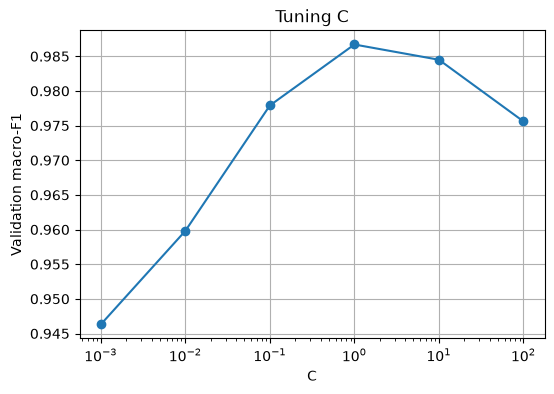

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(tuning_df["C"], tuning_df["val_macro_f1"], marker="o")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Validation macro-F1")
plt.title("Tuning C")
plt.grid(True)
plt.show()

## 5. Train the final model

We train a new SVM with the best C on the training set.


In [6]:
final_model = LinearSVC(C=best_C, random_state=SEED)
final_model.fit(E_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",np.float64(1.0)
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to autom

## 6. Evaluate on the test set

The test set is used only once, here. We use the shared `evaluate()` function
so the results are comparable with the baseline. It prints the per-intent
report, saves the confusion matrix and adds a row to `results/metrics.csv`.

Run this cell once. Running it again appends a duplicate `sbert_svm` row.


In [7]:
test_preds = final_model.predict(E_test)

metrics = evaluate(y_test, test_preds, "sbert_svm", "synthetic_test", out_dir="../results")
metrics

=== sbert_svm on synthetic_test ===
Accuracy: 0.9867   Macro-F1: 0.9866

                     precision    recall  f1-score   support

             abroad       1.00      1.00      1.00        32
            address       1.00      1.00      1.00        32
          app_error       0.97      1.00      0.99        33
          atm_limit       1.00      1.00      1.00        32
            balance       1.00      0.91      0.95        32
      business_loan       1.00      1.00      1.00        33
        card_issues       0.97      0.97      0.97        32
       cash_deposit       1.00      1.00      1.00        33
       direct_debit       0.94      1.00      0.97        32
             freeze       1.00      0.94      0.97        32
 high_value_payment       1.00      1.00      1.00        32
      joint_account       1.00      1.00      1.00        32
latest_transactions       0.94      1.00      0.97        32
           pay_bill       1.00      1.00      1.00        33

          

{'model': 'sbert_svm',
 'dataset': 'synthetic_test',
 'accuracy': 0.9867,
 'macro_f1': 0.9866}

## 7. Save the model

We save only the SVM. Unlike the baseline, this is not a complete pipeline: the encoder
is not saved with it, because it is an unchanged pretrained model that can be loaded again
by name. To classify raw text later, load `all-mpnet-base-v2`, encode the text, then pass
the vectors to this SVM.


In [8]:
os.makedirs("../models", exist_ok=True)
joblib.dump(final_model, "../models/sbert_svm.joblib")
print("Model saved to ../models/sbert_svm.joblib")

Model saved to ../models/sbert_svm.joblib


## 8. Quick demo

Load the saved SVM and classify a few new messages. The wording here deliberately avoids
the obvious keywords, so the predictions depend on meaning rather than on exact word matches.


In [9]:
loaded_model = joblib.load("../models/sbert_svm.joblib")

examples = [
    "my card stopped working while i was abroad",
    "how much have i got left",
    "it keeps shutting down every time i sign in",
]
example_emb = encoder.encode(examples)
for text, intent in zip(examples, loaded_model.predict(example_emb)):
    print(f"{intent:20} <- {text}")

abroad               <- my card stopped working while i was abroad
balance              <- how much have i got left
app_error            <- it keeps shutting down every time i sign in


## 9. Conclusion

- Best C: 1.0
- Test accuracy: 0.9867 | Test macro-F1: 0.9866
- Compared with the TF-IDF baseline (accuracy 0.9403, macro-F1 0.9386): the embedding model brings down errors from 27 to 6 out of the 452 test messages that's around 78% reduction . Something to note is that both models use a linear classifier on the same split so the difference most likely comes mainly from the features(word counts vs meaning vectors), although the classifier also changed (logistic regression to SVM) so it is not a perfectly clean one-variable comparison
- Most confused intents (from the confusion matrix): balance → latest_transactions (2 messages) and freeze → card_issues / app_error (2 messages).Both pairs overlap in meaning rather than being straightforward mistakes: Asking about how much you have left and how much you spent are both questions about account money and freezing a card is kind of a card problem 
- Intents where embeddings helped most over TF-IDF: abroad benefitted the most going from 0.77(10 missed out 32) to 1.0(no missed).As well as card_issues(+0.09) and latest_transactions(+0.08). The main takeaway is that no intent scored worse and balance was unchanged at 0.95 thus we can say that the embedding helped where wording varied but did not fix the overlapping meaning issue .
